# Problem 6

### Problem
$$
\begin{align*}
u(x, y) &= 10\,\varphi(x)\,\varphi(y), \\
\varphi(x) &= e^{-100(x - 1/2)^{2}}(x^{2} - x).
\end{align*}
$$

From the Paper:

PROBLEM 6. To better understand the importance of the use of Fourier representation for functions with rapid variations, let $u(x, y) = 10\,\varphi(x)\varphi(y)$, where $\varphi(x) = e^{-100(x - 1/2)^{2}}(x^{2} - x)$. The solution has a sharp peak at $(0.5, 0.5)$, and it is very small for $(x - 0.5)^{2} + (y - 0.5)^{2} > 0.01$. Figure 6 shows the analytical solution $u$.

For a small number of Fourier coefficients $N = 64$ aliasing occurs and errors of order $10^{-4}$ dominate the circle of radius $r = 0.5$ even if large values of $M$ are used. In fact, Fig. 7 presents the function error for $N = 64$ and $M = 256$ when solving the Dirichlet problem using the trapezoidal rule. If the number of coefficients is increased to $N = 128$, the Fourier space provides a better approximation, and the aliasing effect decreases drastically as one can observe in Fig. 8.

Although the maximum error persists with order $10^{-4}$ in a neighborhood of $(0.5, 0.5)$, globally it decreases for the larger value $N = 128$: Figure 9 contains the errors when only observing the grid points in $B(0; 1)$ on the segment $(-\sqrt{2}/2, -\sqrt{2}/2)$ to $(\sqrt{2}/2, \sqrt{2}/2)$. Specifically, we say that the radial position is equal to $-1$ for the point $(-\sqrt{2}/2, -\sqrt{2}/2)$, and it is $1$ for the point $(\sqrt{2}/2, \sqrt{2}/2)$. The linear plot of the errors presented in Figure 9(a) shows that for $N = 128$ the local error at $(0.5, 0.5)$ persists in the same order but the aliasing effect is negligible at $(-0.5, -0.5)$. Moreover, the log-scale shown in Fig. 9(b) shows the global convergence of the algorithm. Similar results hold for the Neumann problem as shown in Fig. 10.

# Imports

In [1]:
import numpy as np
import warnings
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
import numpy as np
import time
import matplotlib.pyplot as plt
import pandas as pd
import sympy as sp

import os, sys

# Main project root
repo_root = r"C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson"
os.chdir(repo_root)
if repo_root not in sys.path:
    sys.path.append(repo_root)


from Tests.JCP_Paper_Comparisons.JCP_Helpers import (
    get_problem_functions,
    run_table_2,
    display_table_varying_M
)




# Problem Setup

In [2]:
from Tests.JCP_Paper_Comparisons.JCP_Helpers import setup_problem_6

u, f, g_dirichlet, g_neumann = setup_problem_6()

R = 1.0
rad_unif = 0
BC_MAP = {"dirichlet": 1, "neumann": 2}
QUAD_MAP = {"trapezoidal": 1, "simpson": 2}

methods = [
    {"name": "nufft", "label": "NUFFT Method", "azu_unif": 1, "mesh_kind": "rand", "use_nudft": False}
]

N_fixed = 128
M_values = [16, 32, 64, 128, 256]


# Run Code, table 

In [3]:
df_table = run_table_2(methods, N_fixed, M_values, u, f, g_dirichlet, g_neumann, BC_MAP, QUAD_MAP, rad_unif, R)


C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson\Poisson_Solver\cpu_solver\radial\nonuniform.py:143: RuntimeWarning: divide by zero encountered in scalar divide
  * (r_ip1 / r_im1) ** k
C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson\Poisson_Solver\cpu_solver\radial\radial.py:92: RuntimeWarning: divide by zero encountered in scalar divide
  ratio = r_m[i] / r_m[i - 2]
C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson\Poisson_Solver\cpu_solver\radial\nonuniform.py:143: RuntimeWarning: divide by zero encountered in scalar divide
  * (r_ip1 / r_im1) ** k
C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson\Poisson_Solver\cpu_solver\radial\radial.py:92: RuntimeWarning: divide by zero encountered in scalar divide
  ratio = r_m[i] / r_m[i - 2]
C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson\Poisson_Solver\cpu_solver\radial\nonuniform.py:143: RuntimeWarning: divide by zero encountered in scalar divide
  * (r_ip1 / r_im1) ** k
C:\Users\charl\OneDrive\Docume

# View Results

In [4]:
display_table_varying_M(df_table, methods, M_values, title="PROBLEM 6")



NUFFT Method : PROBLEM 6


Trapezoidal rule                             Simpson rule           \
           Dirichlet            Neumann             Dirichlet            
           L_inf_rel   L2_rel L_inf_rel   L2_rel    L_inf_rel   L2_rel   
M                                                                        
16           2.1e-01  6.5e-01   3.3e-01  1.6e+00      2.0e-01  6.5e-01   
32           1.9e-01  6.5e-01   3.1e-01  1.6e+00      1.9e-01  6.5e-01   
64           1.9e-01  6.5e-01   3.1e-01  1.6e+00      1.9e-01  6.5e-01   
128          1.9e-01  6.5e-01   3.1e-01  1.6e+00      1.9e-01  6.5e-01   
256          1.9e-01  6.5e-01   3.1e-01  1.6e+00      1.9e-01  6.5e-01   

                        
      Neumann           
    L_inf_rel   L2_rel  
M                       
16    3.3e-01  1.6e+00  
32    3.1e-01  1.6e+00  
64    3.1e-01  1.6e+00  
128   3.1e-01  1.6e+00  
256   3.1e-01  1.6e+00

## Figures from Original Paper

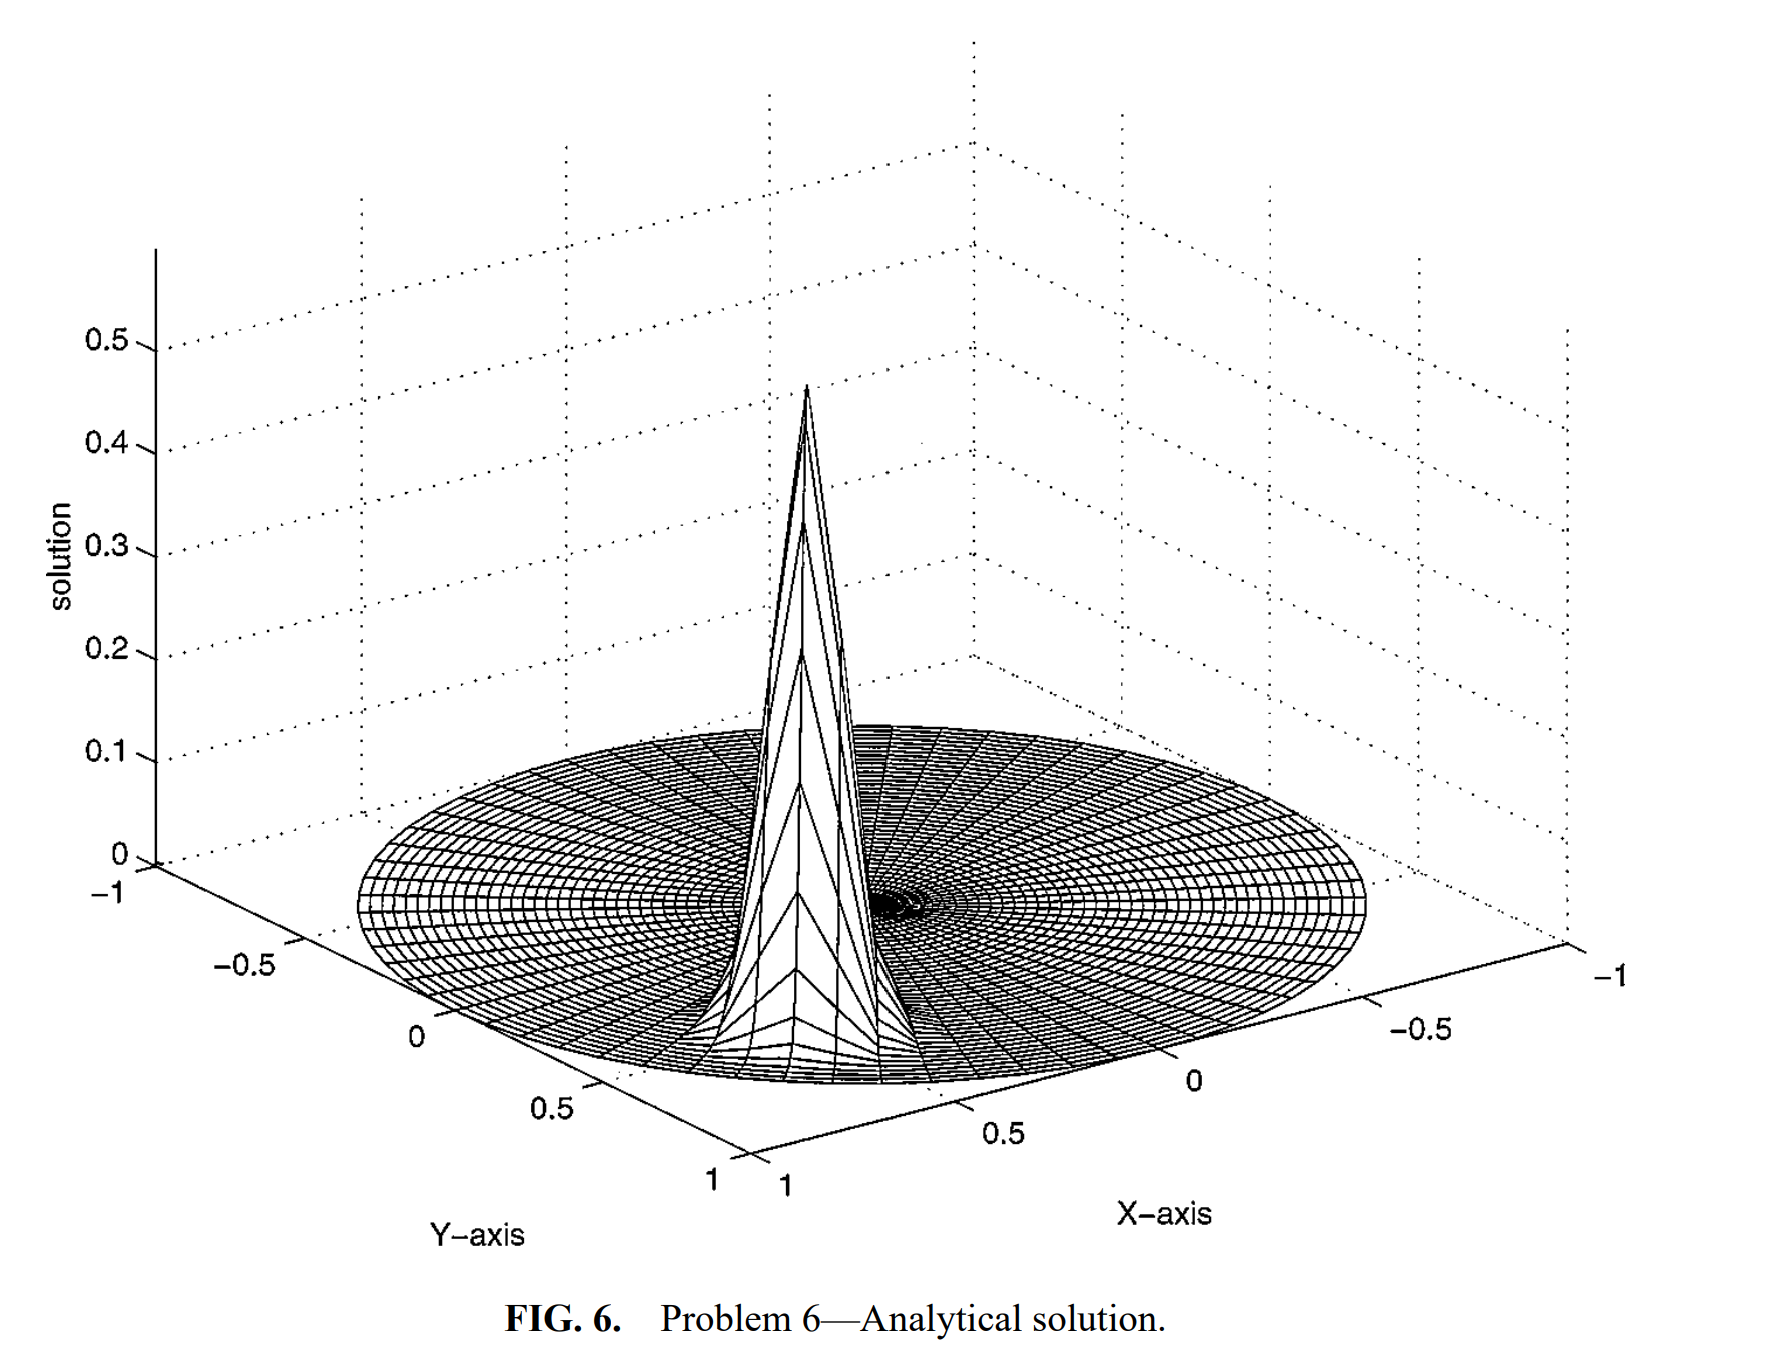

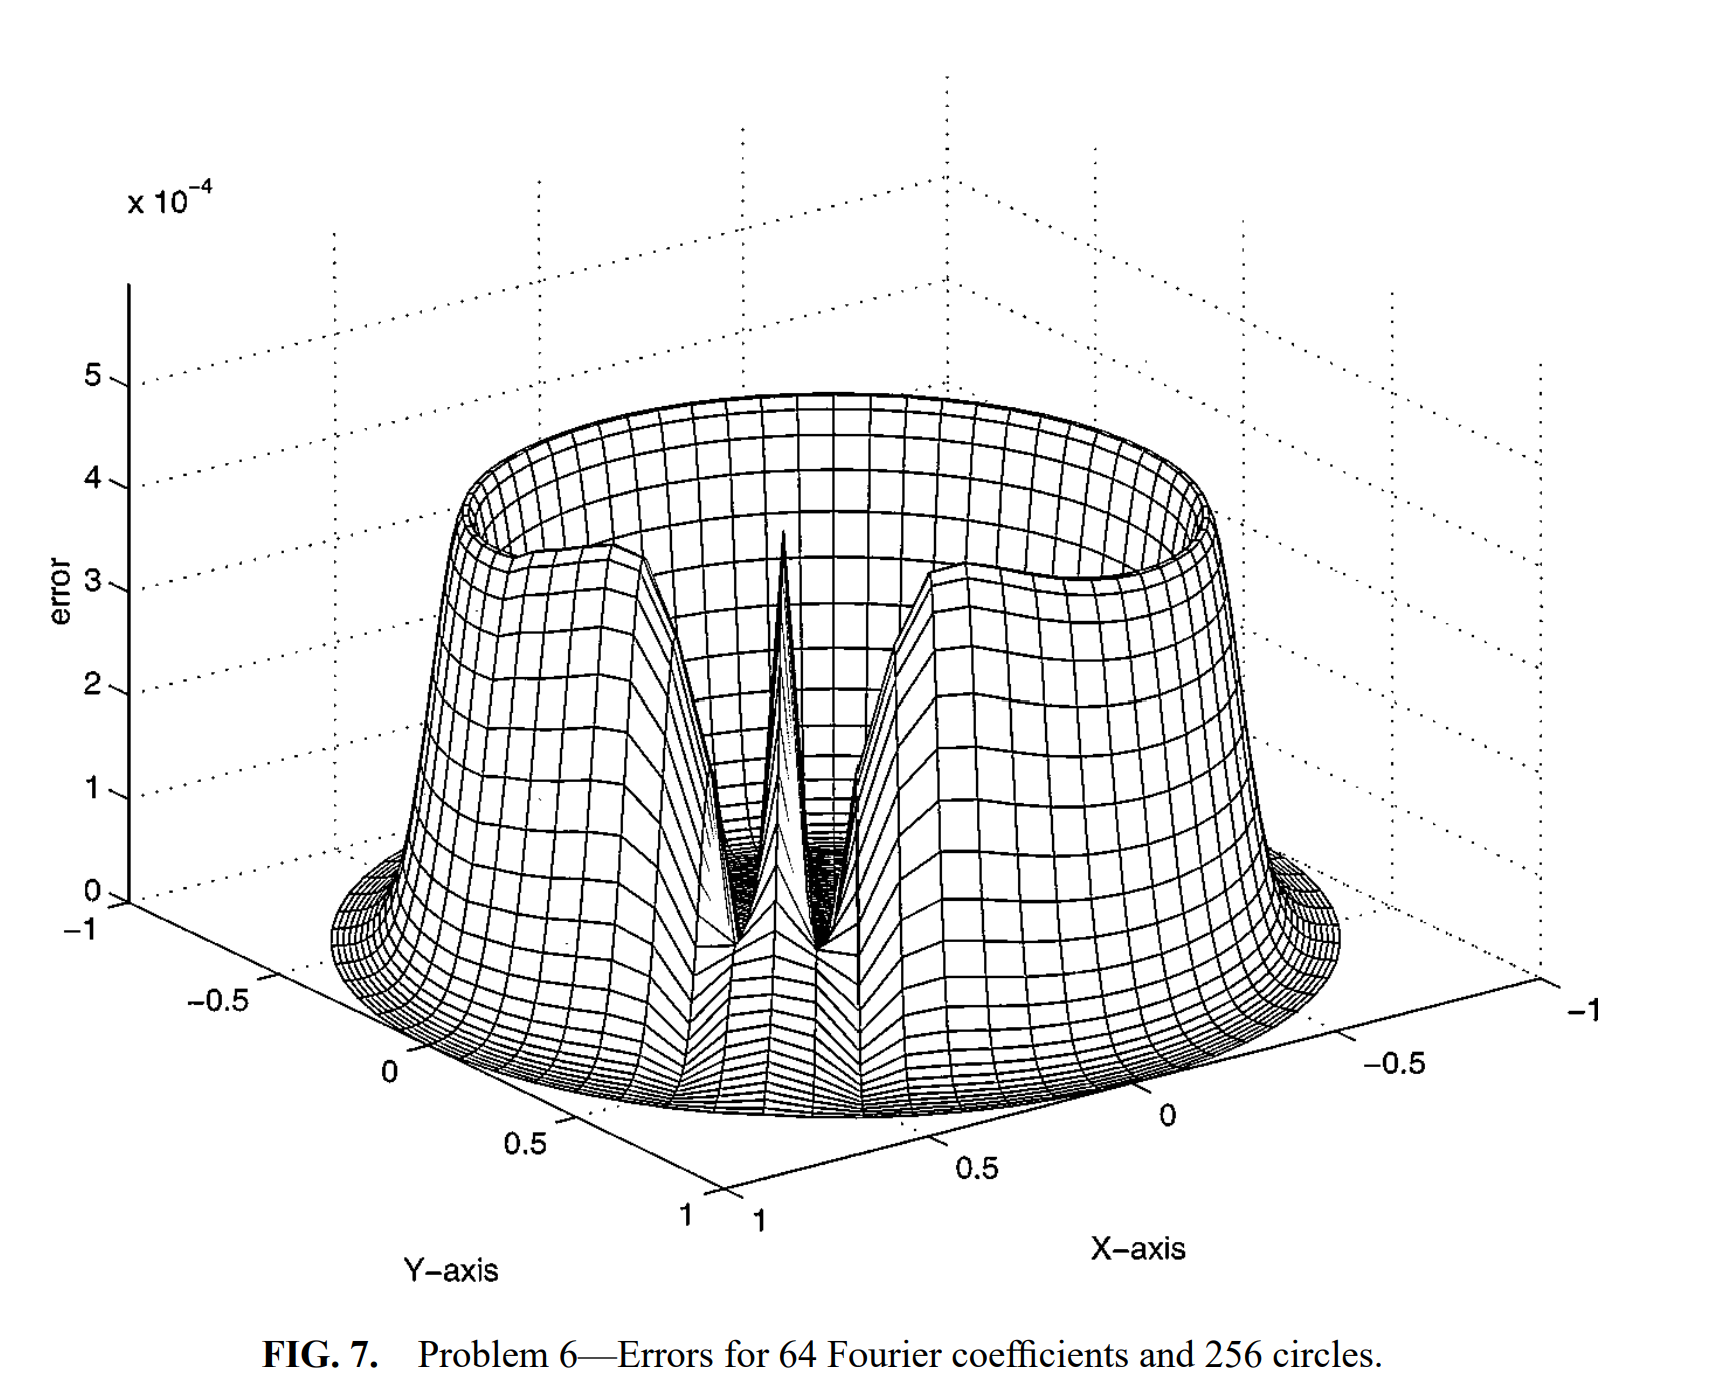

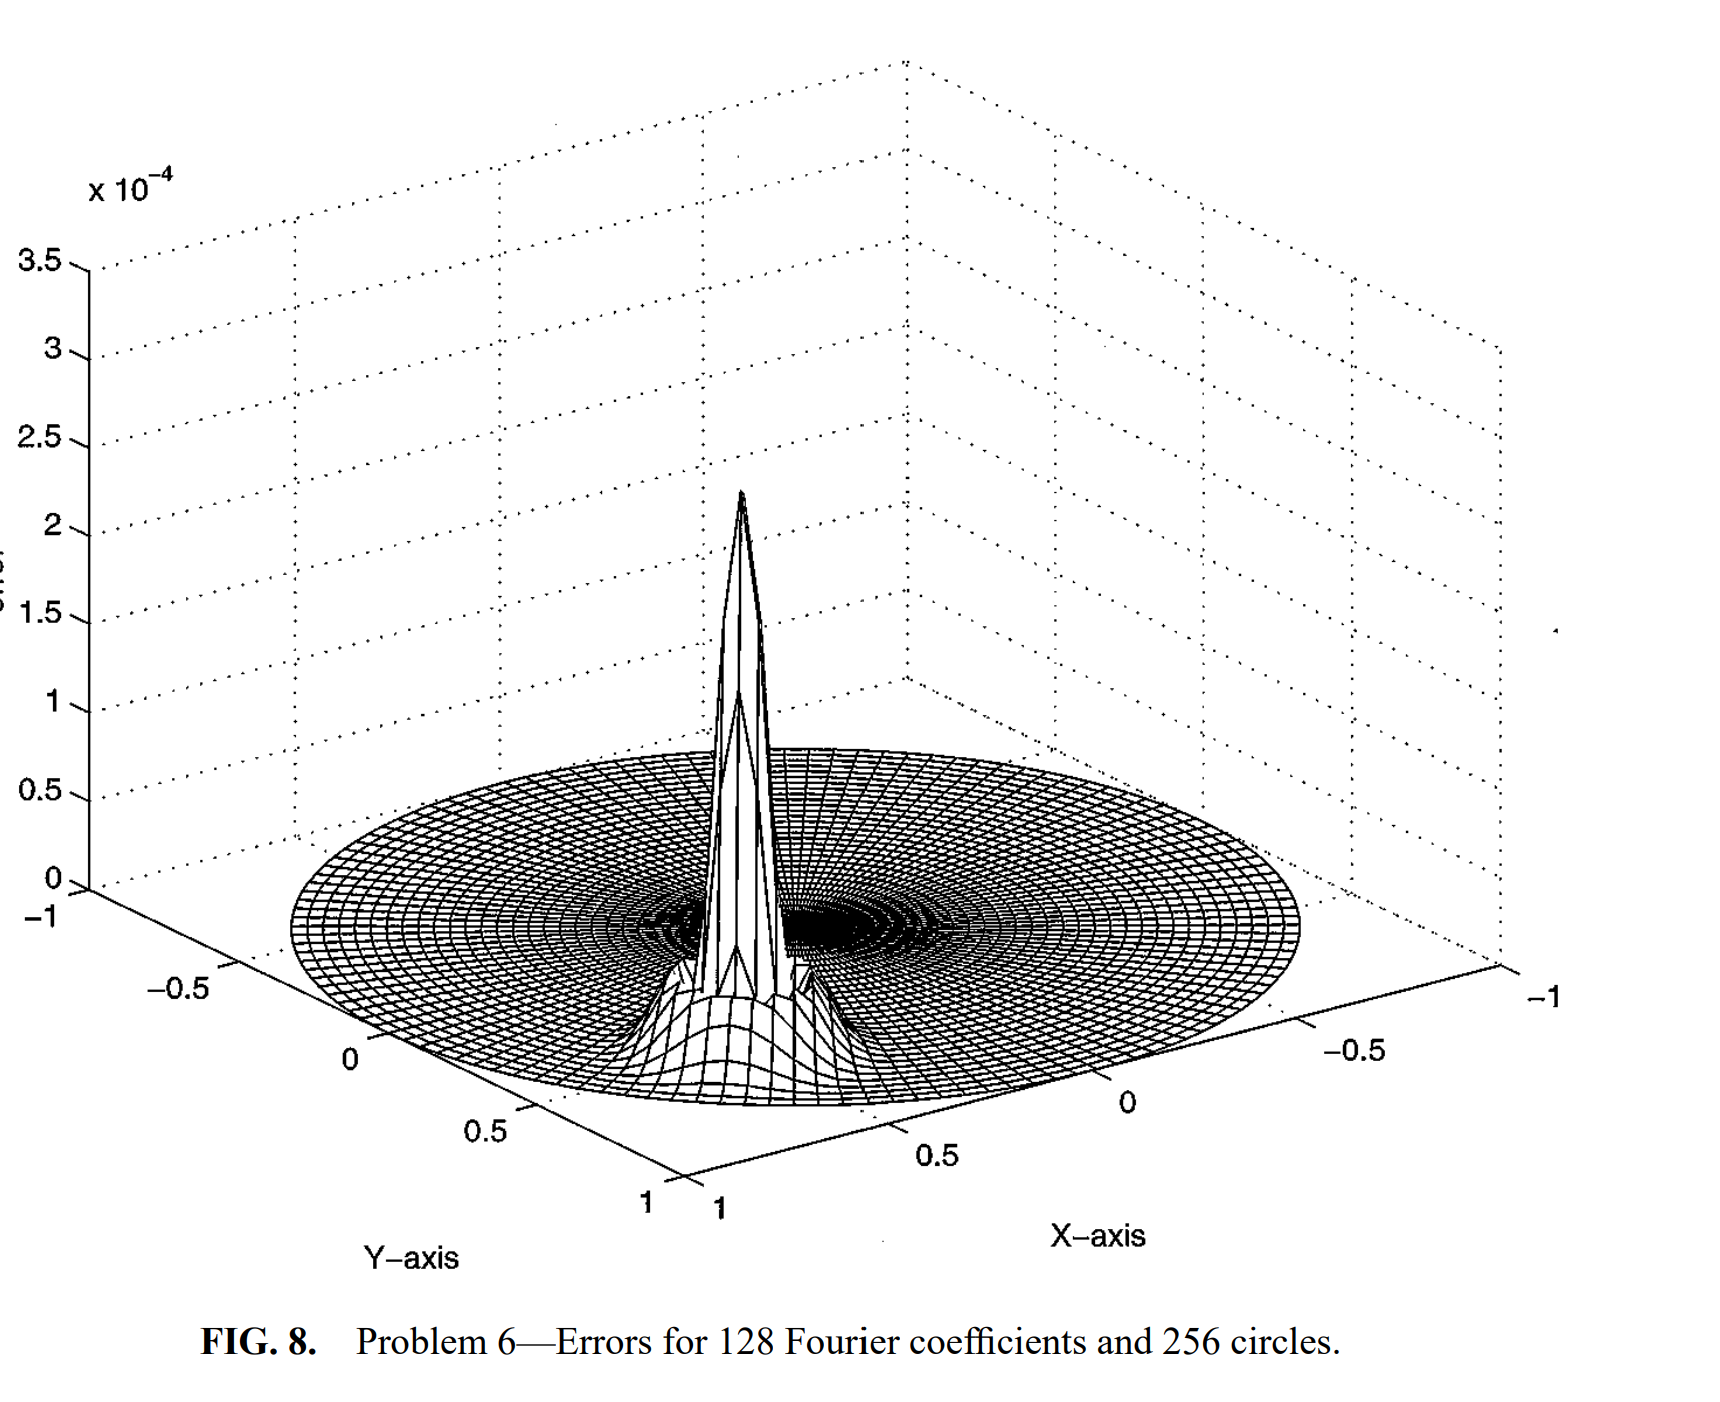